# My Content — Exploration & modélisation

Prototypage du système de recommandation d'articles.

1. Exploration des données (clics, articles, embeddings)
2. Approche *content-based* (similarité de contenu)
3. Approche *collaborative filtering* (ALS, feedback implicite)
4. Comparaison et recommandation top-5

> Prérequis : données placées dans `data/raw/` (voir `data/README.md`).

### 0. Contrôle de l'environnement d'exécution

Affiche le chemin de l'interpréteur Python utilisé par le kernel.

**Pourquoi ?** Vérifier que le notebook tourne bien dans l'environnement virtuel du projet
(`.venv/Scripts/python.exe`) et non dans un Python système. Si le chemin ne contient pas
`.venv`, les imports `numpy` / `pandas` / `implicit` risquent d'échouer ou de pointer vers
d'autres versions : il faut alors changer de kernel dans VS Code (*Select Kernel*).

In [2]:
import sys;
print(sys.executable)

c:\Users\darya\Desktop\OpenClassRooms\Project 10\Ricochet-content-recommendation\.venv\Scripts\python.exe


### Imports et chemins de travail

Charge les dépendances communes à tout le notebook et définit deux répertoires :

| Objet | Rôle |
|---|---|
| `pickle` | lecture des embeddings d'articles (fournis au format pickle) |
| `Path` | chemins portables (Windows / Linux) |
| `numpy`, `pandas` | manipulation des matrices et des tables de clics |
| `matplotlib.pyplot` | histogrammes de la section 1 |
| `DATA` | `../data/news-portal-user` → données brutes Globo.com (lecture seule) |
| `MODELS` | `../models` → artefacts générés par le pipeline hors-ligne (écriture) |

Les chemins sont **relatifs au dossier `notebooks/`** : le notebook doit donc être exécuté
depuis ce dossier.

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path('..') / 'data' / 'news-portal-user'
MODELS = Path('..') / 'models'

## 1. Exploration

### 1.1 Catalogue d'articles (`articles_metadata.csv`)

Lit les métadonnées du catalogue, affiche sa dimension (`shape`) puis les 5 premières lignes.

Colonnes attendues :
- `article_id` — identifiant de l'article ; il sert d'**index de ligne** dans la matrice
  d'embeddings (article_id 0 → ligne 0), propriété exploitée par le moteur *content-based* ;
- `category_id` — rubrique éditoriale ;
- `created_at_ts` — date de publication (timestamp en millisecondes) ;
- `publisher_id` — éditeur ;
- `words_count` — longueur de l'article en mots.

**À retenir :** ~364 000 articles au catalogue, à comparer au nombre bien plus faible
d'articles réellement cliqués (cellule suivante) → forte *long tail* et enjeu de cold start
sur les articles.

In [3]:
articles = pd.read_csv(DATA / 'articles_metadata.csv')
print(articles.shape)
articles.head()

(364047, 5)


,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162


### 1.2 Interactions utilisateur → article (les clics)

1. `sys.path.append('..')` rend le package `src/` importable depuis `notebooks/` (le notebook
   n'est pas à la racine du projet).
2. `load_clicks(DATA)` (défini dans `src/prepare_model.py`) charge les clics de façon
   tolérante :
   - si un dossier `clicks/` existe → concatène tous les `clicks_hour_*.csv` (jeu complet) ;
   - sinon → lit `clicks_sample.csv` (échantillon de démo) ;
   - sinon → lève `FileNotFoundError` en renvoyant vers `data/README.md`.

   Seules 3 colonnes sont chargées : `user_id`, `click_article_id`, `click_timestamp`.
3. Affiche le volume d'interactions, le nombre d'utilisateurs et d'articles distincts.

**Lecture de la sortie :** ici 1 883 interactions / 707 utilisateurs / 323 articles — c'est
l'**échantillon**, pas le jeu complet. Peu de clics par utilisateur (≈ 2,7 en moyenne) : cela
explique les scores d'évaluation modestes de la section 4 et justifie le repli sur la
popularité en cold start.

In [4]:
# Chargement des clics (dossier clicks/ ou clicks_sample.csv)
import sys; sys.path.append('..')
from src.prepare_model import load_clicks

clicks = load_clicks(DATA)
print(f'{len(clicks):,} interactions')
print(f"{clicks['user_id'].nunique():,} utilisateurs, "
      f"{clicks['click_article_id'].nunique():,} articles cliqués")
clicks.head()

1,883 interactions
707 utilisateurs, 323 articles cliqués


,user_id,click_article_id,click_timestamp,click_region
0,0,157541,1506826828020,20
1,0,68866,1506826858020,20
2,1,235840,1506827017951,16
3,1,96663,1506827047951,16
4,2,119592,1506827090575,24


### 1.3 Trois distributions clés

Trace côte à côte (`plt.subplots(1, 3)`) les histogrammes qui caractérisent la difficulté du
problème. Les deux premiers sont en **échelle logarithmique** (`logy=True`) car les
distributions sont très déséquilibrées :

| Graphe | Calcul | Ce qu'on cherche à voir |
|---|---|---|
| **Clics par utilisateur** | `clicks.groupby('user_id').size()` | volume d'historique disponible par utilisateur → capacité à construire un profil |
| **Popularité des articles** | `clicks['click_article_id'].value_counts()` | concentration des clics sur quelques articles (*long tail*) |
| **Nombre de mots par article** | `articles['words_count']` | homogénéité du catalogue (longueur des contenus) |

`plt.tight_layout()` évite le chevauchement des titres et des axes.

**Interprétation attendue :** décroissance quasi exponentielle sur les deux premiers graphes
→ la majorité des utilisateurs ont très peu de clics et la majorité des articles ne sont
presque jamais cliqués. C'est l'argument principal en faveur d'une approche **hybride**
(contenu pour les profils pauvres, collaboratif pour les utilisateurs actifs).

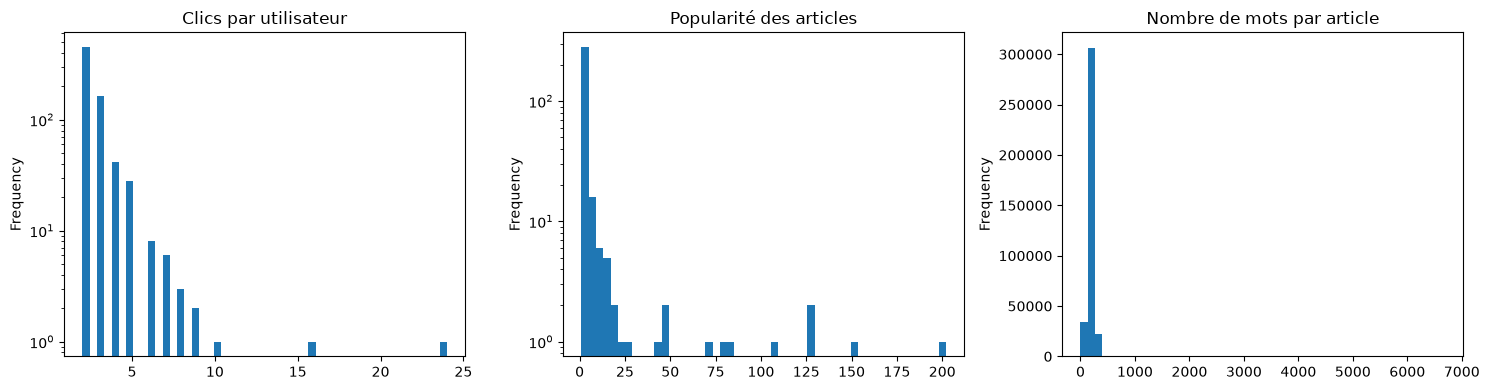

In [5]:
# Distributions clés : clics par utilisateur, popularité des articles, longueur
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
clicks.groupby('user_id').size().plot.hist(bins=50, ax=axes[0], logy=True)
axes[0].set_title('Clics par utilisateur')
clicks['click_article_id'].value_counts().plot.hist(bins=50, ax=axes[1], logy=True)
axes[1].set_title('Popularité des articles')
articles['words_count'].plot.hist(bins=50, ax=axes[2])
axes[2].set_title("Nombre de mots par article")
plt.tight_layout()

### 1.4 Embeddings d'articles (`articles_embeddings.pickle`)

Dépickle la matrice d'embeddings fournie avec le dataset et la convertit en `np.float32`
(moitié de mémoire par rapport au `float64`), puis affiche sa forme.

- Forme = `(nb_articles, dim)` ≈ **(364 047, 250)** : une ligne par article, alignée sur
  `article_id`.
- Ces vecteurs sont le **seul signal de contenu** utilisé : ils encodent le texte de
  l'article, on n'a donc pas besoin du texte brut.
- Poids en mémoire : ~364 000 × 250 × 4 octets ≈ **360 Mo** → trop lourd pour le free tier
  Azure Functions, d'où la réduction par **ACP** en section 2.

⚠️ Cellule la plus gourmande du notebook en RAM ; si le kernel meurt ici, c'est un problème
de mémoire disponible, pas de code.

In [6]:
# Embeddings d'articles
with open(DATA / 'articles_embeddings.pickle', 'rb') as f:
    embeddings = np.asarray(pickle.load(f), dtype=np.float32)
print('Forme des embeddings :', embeddings.shape)

Forme des embeddings : (364047, 250)


## 2. Génération des artefacts

On exécute le pipeline hors-ligne (ACP, historique de clics, popularité, ALS).
Équivaut à `python -m src.prepare_model --data-dir data/raw --out-dir models`.

### 2.1 Exécution du pipeline hors-ligne

Crée `models/` si besoin (`mkdir(exist_ok=True)`) puis appelle les trois constructeurs
d'artefacts de `src/prepare_model.py`. Chaque fonction écrit ses fichiers dans `MODELS` et
log un résumé.

| Appel | Ce qu'il fait | Fichiers produits dans `models/` |
|---|---|---|
| `build_embeddings_pca(DATA, MODELS, n_components=50)` | ACP 250 → **50** dimensions (`random_state=42`), cast `float32` | `articles_embeddings_pca.npy` (~73 Mo au lieu de ~360) |
| `build_user_artifacts(clicks, MODELS)` | trie les clics par `click_timestamp`, dédoublonne par utilisateur (ordre chronologique conservé) et calcule le classement de popularité globale | `user_clicks.pkl` (dict `user_id → array(article_id)`), `popular_articles.npy` |
| `build_collaborative(clicks, MODELS, factors=50)` | ré-encode les id creux en indices denses, construit la matrice creuse *user × item* (valeur = 1 par clic = confiance implicite) et entraîne un **ALS** (`implicit`, 15 itérations, `regularization=0.05`) | `cf_user_factors.npy`, `cf_item_factors.npy`, `cf_item_ids.npy`, `cf_user_index.pkl` |

**Points d'attention :**
- Si le package `implicit` n'est pas installé, `build_collaborative` **n'échoue pas** : il
  affiche un avertissement et saute le collaboratif. Les méthodes `collab` / `hybrid` de la
  section 3 se rabattront alors sur le contenu ou la popularité.
- L'ordre chronologique de `user_clicks` est essentiel : l'évaluation de la section 4 masque
  *le dernier clic*, ce qui n'a de sens que si l'historique est trié dans le temps.
- Cellule la plus longue à exécuter (ACP sur 364 k vecteurs + entraînement ALS).
- Équivalent CLI : `python -m src.prepare_model --data-dir data/raw --out-dir models`.

In [7]:
from src.prepare_model import (build_embeddings_pca, build_user_artifacts,
                               build_collaborative)
MODELS.mkdir(exist_ok=True)
build_embeddings_pca(DATA, MODELS, n_components=50)
build_user_artifacts(clicks, MODELS)
build_collaborative(clicks, MODELS, factors=50)

[embeddings] (364047, 250) -> ACP (364047, 50) (~72.8 Mo)
[pca] projection sauvegardée : 50 composantes, 94.5% de variance expliquée
[user_clicks] 707 utilisateurs
[popular_articles] 323 articles classés


  0%|          | 0/15 [00:00<?, ?it/s]

[collab] ALS entraîné : 707 users x 323 items, 50 facteurs


## 3. Recommandations top-5

### 3.1 Instanciation du moteur et comparaison des trois stratégies

`Recommender(MODELS)` charge **uniquement les artefacts** (aucun ré-entraînement) : c'est le
code exact utilisé par l'Azure Function, il ne dépend que de `numpy`. Au chargement, les
embeddings ACP sont normalisés L2, ce qui permet de calculer un cosinus par simple produit
scalaire.

On prend ensuite le premier utilisateur du jeu de clics et on lui demande un top-5 selon les
trois stratégies :

| `method` | Principe | Comportement si indisponible |
|---|---|---|
| `content` | profil = **moyenne des embeddings** des articles lus, puis cosinus contre tout le catalogue | `None` si aucun historique → repli popularité |
| `collab` | score = `facteurs_articles · facteurs_utilisateur` (ALS pré-entraîné) | `None` si pas d'artefacts CF ou utilisateur absent du modèle → repli popularité |
| `hybrid` | moyenne pondérée (`alpha=0.5`) des deux scores **min-max normalisés** ; se réduit au contenu si l'utilisateur est inconnu du CF | idem |

Dans tous les cas, les articles **déjà cliqués sont exclus** (score forcé à `-inf`) et le
top-N est extrait par `argpartition` — un tri partiel, pour éviter de trier 364 k scores.

Le dernier appel, `reco.recommend(-1, n=5)`, teste le **cold start** : l'id `-1` n'existe pas,
donc la méthode retombe sur `_popularity_fallback` et renvoie les 5 articles les plus
populaires. C'est le comportement de référence pour tout nouvel utilisateur en production.

In [8]:
from src.recommender import Recommender

reco = Recommender(MODELS)
sample_user = clicks['user_id'].iloc[0]
for method in ['content', 'collab', 'hybrid']:
    print(method, '->', reco.recommend(int(sample_user), n=5, method=method))
print('cold start (user inconnu) ->', reco.recommend(-1, n=5))

content -> [157519, 157944, 159495, 156690, 162857]
collab -> [157485, 158189, 156718, 19839, 106799]
hybrid -> [157519, 157944, 159495, 156690, 157485]
cold start (user inconnu) -> [119592, 96663, 284847, 108854, 235840]


## 4. Évaluation (leave-last-out)

Pour chaque utilisateur ayant assez d'historique, on masque son dernier clic et
on vérifie s'il apparaît dans le top-N recommandé (**Recall@5**, **Hit Rate**).

### 4.1 Protocole *leave-last-out* et calcul du Hit Rate@5

`evaluate(method, n=5, max_users=1000)` implémente le protocole suivant, pour au plus
`max_users` utilisateurs de `reco.user_clicks` :

1. **Filtre** — on ignore les utilisateurs ayant moins de 2 clics (impossible de masquer un
   clic tout en gardant un profil).
2. **Masquage** — `held_out = arts[-1]` : le **dernier clic chronologique** devient la vérité
   terrain, et `reco.user_clicks[user_id]` est temporairement remplacé par `arts[:-1]`.
   Cette réécriture *en place* du dictionnaire est ce qui empêche le modèle de « voir » la
   réponse (aussi bien dans le profil de contenu que dans la liste d'exclusion).
3. **Prédiction** — `reco.recommend(user_id, n=n, method=method)` produit un top-N.
4. **Restauration** — `reco.user_clicks[user_id] = arts` remet l'historique complet, pour que
   les évaluations successives (`content`, `collab`, `hybrid`) partent du même état.
5. **Score** — `hits += held_out in recs` ; on renvoie `hits / total`, soit le **Hit Rate@N**
   (identique au **Recall@N** ici, puisqu'il n'y a qu'un seul item pertinent par utilisateur).

La boucle finale affiche la métrique pour les trois stratégies, ce qui donne la comparaison
chiffrée qui justifie le choix de la méthode par défaut.

**Limites à garder en tête :**
- ⚠️ Les **facteurs ALS n'ont pas été ré-entraînés** sans le clic masqué : le modèle `collab`
  (et la part collaborative de `hybrid`) a vu cet item pendant l'entraînement, son score est
  donc **optimiste**. Comparaison indicative, pas une évaluation rigoureuse.
- Métrique binaire et sans notion de rang : un item trouvé en position 1 ou 5 compte pareil
  (un MAP@5 ou NDCG@5 serait plus fin).
- Les valeurs sont basses sur l'échantillon de démo (peu de clics par utilisateur) ; il faut
  le jeu complet pour un chiffre représentatif.

In [9]:
def evaluate(method, n=5, max_users=1000):
    hits = total = 0
    for user_id, arts in list(reco.user_clicks.items())[:max_users]:
        if len(arts) < 2:
            continue
        held_out = int(arts[-1])
        reco.user_clicks[user_id] = arts[:-1]  # masque le dernier clic
        recs = reco.recommend(user_id, n=n, method=method)
        reco.user_clicks[user_id] = arts       # restaure
        hits += held_out in recs
        total += 1
    return hits / total if total else 0.0

for m in ['content', 'collab', 'hybrid']:
    print(f'{m:8s} HitRate@5 = {evaluate(m):.4f}')

content  HitRate@5 = 0.0057
collab   HitRate@5 = 0.9392
hybrid   HitRate@5 = 0.8147
